<!-- ### PART 1: SETUP & DATA LOADING -->

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# load the dataset
df = pd.read_excel('Dataset for Data Analytics (1).xlsx', parse_dates=['Date'])
print("Shape:", df.shape)
print(df.head())

Shape: (1200, 14)
     OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000 2023-01-04     C72649  Monitor         5     570.62   
1  ORD200001 2024-08-23     C75739    Phone         2     151.35   
2  ORD200002 2024-02-27     C81728   Tablet         5     550.68   
3  ORD200003 2023-10-15     C33540    Chair         1     273.19   
4  ORD200004 2025-05-08     C81840  Printer         4     626.01   

  ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0     928 Main St    Debit Card     Shipped    TRK37947903            7   
1     823 Main St        Online     Shipped    TRK91186779            3   
2     512 Main St   Credit Card   Cancelled    TRK42903982            8   
3     275 Main St    Debit Card    Returned    TRK62788070            5   
4     668 Main St        Online   Delivered    TRK29241424            8   

  CouponCode ReferralSource  TotalPrice  
0     SAVE10      Instagram     2853.10  
1     SAVE10       Referral      302.7

<!-- ###  PART 2: EXPLORATORY DATA ANALYSIS (EDA) -->

In [3]:
# 2.1 Basic Overview 
print("\n=== DATA TYPES ===")
print(df.dtypes)
 
print("\n=== STATISTICAL SUMMARY ===")
print(df.describe())
 
print("\n=== MISSING VALUES ===")
print(df.isnull().sum())
# Only CouponCode has 309 missing values (people who used no coupon)


=== DATA TYPES ===
OrderID                    object
Date               datetime64[ns]
CustomerID                 object
Product                    object
Quantity                    int64
UnitPrice                 float64
ShippingAddress            object
PaymentMethod              object
OrderStatus                object
TrackingNumber             object
ItemsInCart                 int64
CouponCode                 object
ReferralSource             object
TotalPrice                float64
dtype: object

=== STATISTICAL SUMMARY ===
                      Date     Quantity    UnitPrice  ItemsInCart   TotalPrice
count                 1200  1200.000000  1200.000000  1200.000000  1200.000000
mean   2024-03-22 16:58:48     2.945833   356.412750     5.485000  1053.968300
min    2023-01-01 00:00:00     1.000000    11.390000     1.000000    11.390000
25%    2023-08-03 18:00:00     2.000000   186.062500     4.000000   410.520000
50%    2024-03-23 00:00:00     3.000000   364.210000     5.000000 

In [4]:
 # 2.2 Handle Missing Values

df['CouponCode'] = df['CouponCode'].fillna('NoCoupon')
print("\nMissing after fill:", df.isnull().sum().sum())

 


Missing after fill: 0


In [5]:
# 2.3 Feature Engineering
df['Year']       = df['Date'].dt.year
df['Month']      = df['Date'].dt.month
df['DayOfWeek']  = df['Date'].dt.dayofweek    # 0=Mon … 6=Sun
df['Quarter']    = df['Date'].dt.quarter
df['PricePerUnit_check'] = (df['TotalPrice'] / df['Quantity']).round(2)  # verify data
df['HasCoupon']  = (df['CouponCode'] != 'NoCoupon').astype(int)
 
print("\nNew columns:", ['Year','Month','DayOfWeek','Quarter','HasCoupon'])


New columns: ['Year', 'Month', 'DayOfWeek', 'Quarter', 'HasCoupon']


Text(0.5, 0.98, 'Univariate Analysis')

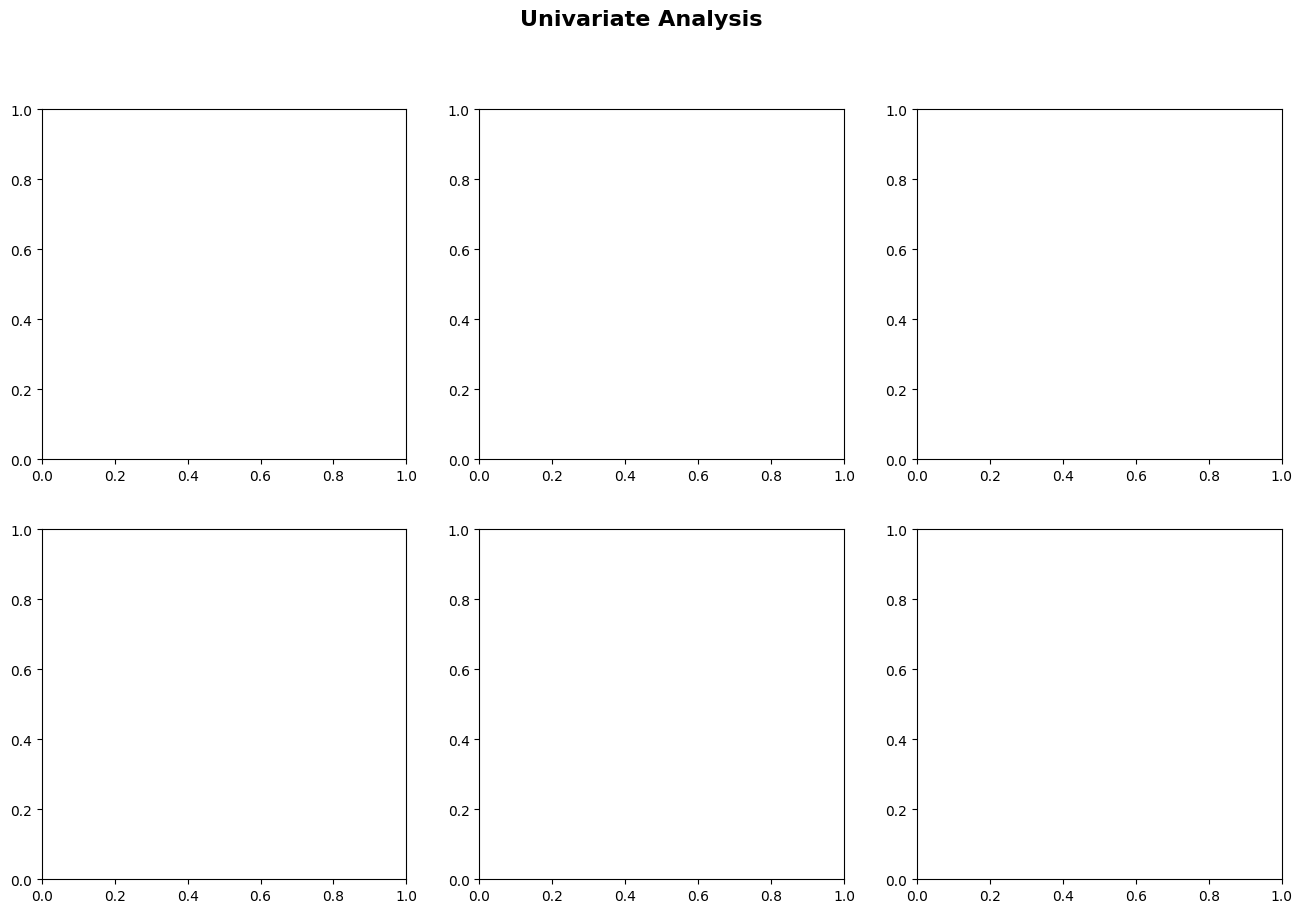

In [6]:
# 2.4 Univariate Analysis 
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Univariate Analysis', fontsize=16, fontweight='bold')

In [7]:
# TotalPrice distribution
axes[0,0].hist(df['TotalPrice'], bins=30, color='steelblue', edgecolor='white')
axes[0,0].set_title('TotalPrice Distribution')
axes[0,0].set_xlabel('Total Price ($)')

Text(0.5, 424.44444444444446, 'Total Price ($)')

In [8]:
# Quantity
axes[0,1].bar(df['Quantity'].value_counts().index,
              df['Quantity'].value_counts().values, color='coral')
axes[0,1].set_title('Quantity Distribution')
axes[0,1].set_xlabel('Quantity Ordered')

Text(0.5, 424.44444444444446, 'Quantity Ordered')

In [9]:
# Product frequency
prod_counts = df['Product'].value_counts()
axes[0,2].barh(prod_counts.index, prod_counts.values, color='mediumseagreen')
axes[0,2].set_title('Orders by Product')

Text(0.5, 1.0, 'Orders by Product')

In [10]:
# Payment method
pay_counts = df['PaymentMethod'].value_counts()
axes[1,0].pie(pay_counts, labels=pay_counts.index, autopct='%1.1f%%', startangle=90)
axes[1,0].set_title('Payment Methods')

Text(0.5, 1.0, 'Payment Methods')

In [11]:
# Order Status
status_counts = df['OrderStatus'].value_counts()
axes[1,1].bar(status_counts.index, status_counts.values, color='mediumpurple')
axes[1,1].set_title('Order Status')
axes[1,1].tick_params(axis='x', rotation=30)

In [12]:
# Referral Source
ref_counts = df['ReferralSource'].value_counts()
axes[1,2].bar(ref_counts.index, ref_counts.values, color='goldenrod')
axes[1,2].set_title('Referral Source')
axes[1,2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('01_univariate_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 01_univariate_analysis.png")
 

<Figure size 640x480 with 0 Axes>

Saved: 01_univariate_analysis.png


Text(0.5, 0.98, 'Bivariate Analysis')

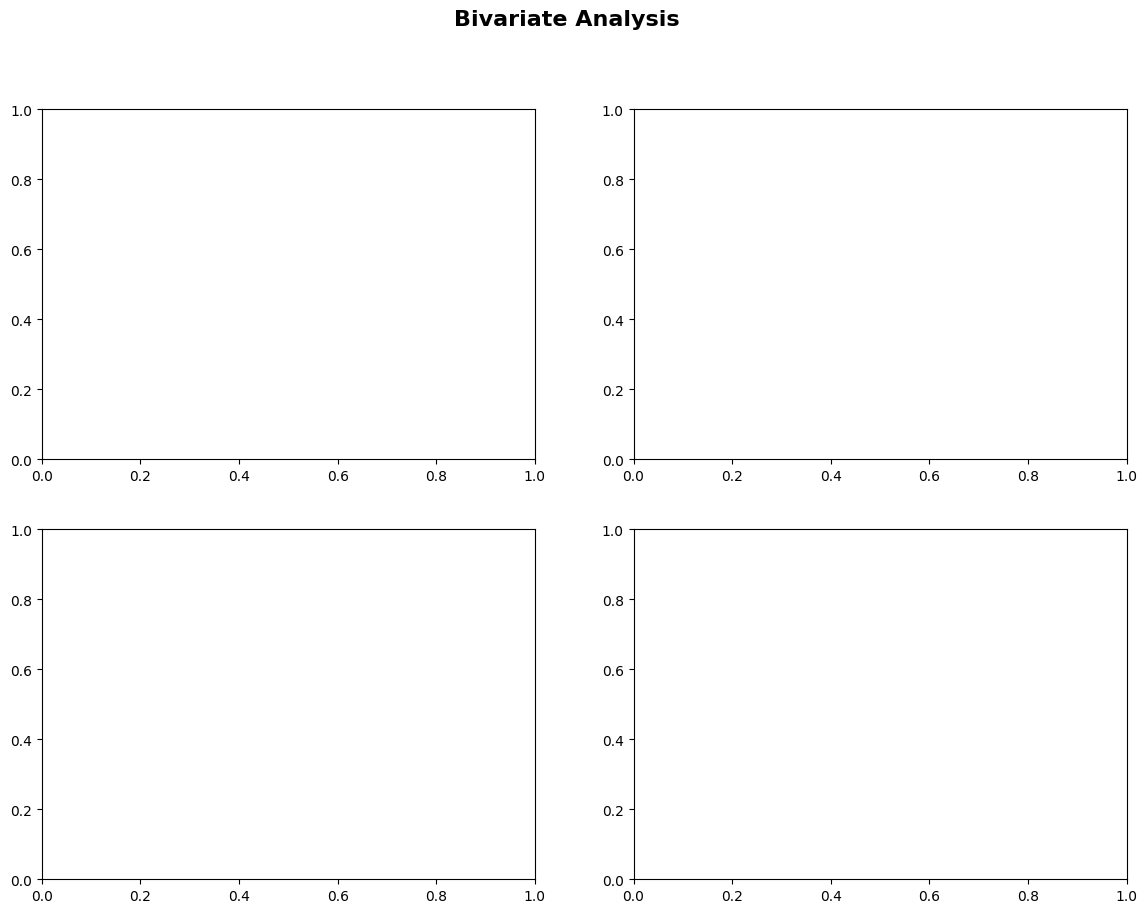

In [13]:
#  2.5 Bivariate Analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Bivariate Analysis', fontsize=16, fontweight='bold')

In [14]:
# Average TotalPrice by Product
avg_price = df.groupby('Product')['TotalPrice'].mean().sort_values(ascending=False)
axes[0,0].bar(avg_price.index, avg_price.values, color='teal')
axes[0,0].set_title('Avg Order Value by Product')
axes[0,0].set_ylabel('Avg Total Price ($)')
axes[0,0].tick_params(axis='x', rotation=30)

In [15]:
# TotalPrice by Order Status
df.boxplot(column='TotalPrice', by='OrderStatus', ax=axes[0,1])
axes[0,1].set_title('Price Distribution by Order Status')
axes[0,1].set_xlabel('Order Status')
plt.sca(axes[0,1])
plt.xticks(rotation=30)
 

(array([1, 2, 3, 4, 5]),
 [Text(1, 0, 'Cancelled'),
  Text(2, 0, 'Delivered'),
  Text(3, 0, 'Pending'),
  Text(4, 0, 'Returned'),
  Text(5, 0, 'Shipped')])

In [16]:
# Revenue by Referral Source
avg_ref = df.groupby('ReferralSource')['TotalPrice'].mean().sort_values(ascending=False)
axes[1,0].bar(avg_ref.index, avg_ref.values, color='salmon')
axes[1,0].set_title('Avg Revenue by Referral Source')
axes[1,0].set_ylabel('Avg Total Price ($)')

Text(102.72222222222221, 0.5, 'Avg Total Price ($)')

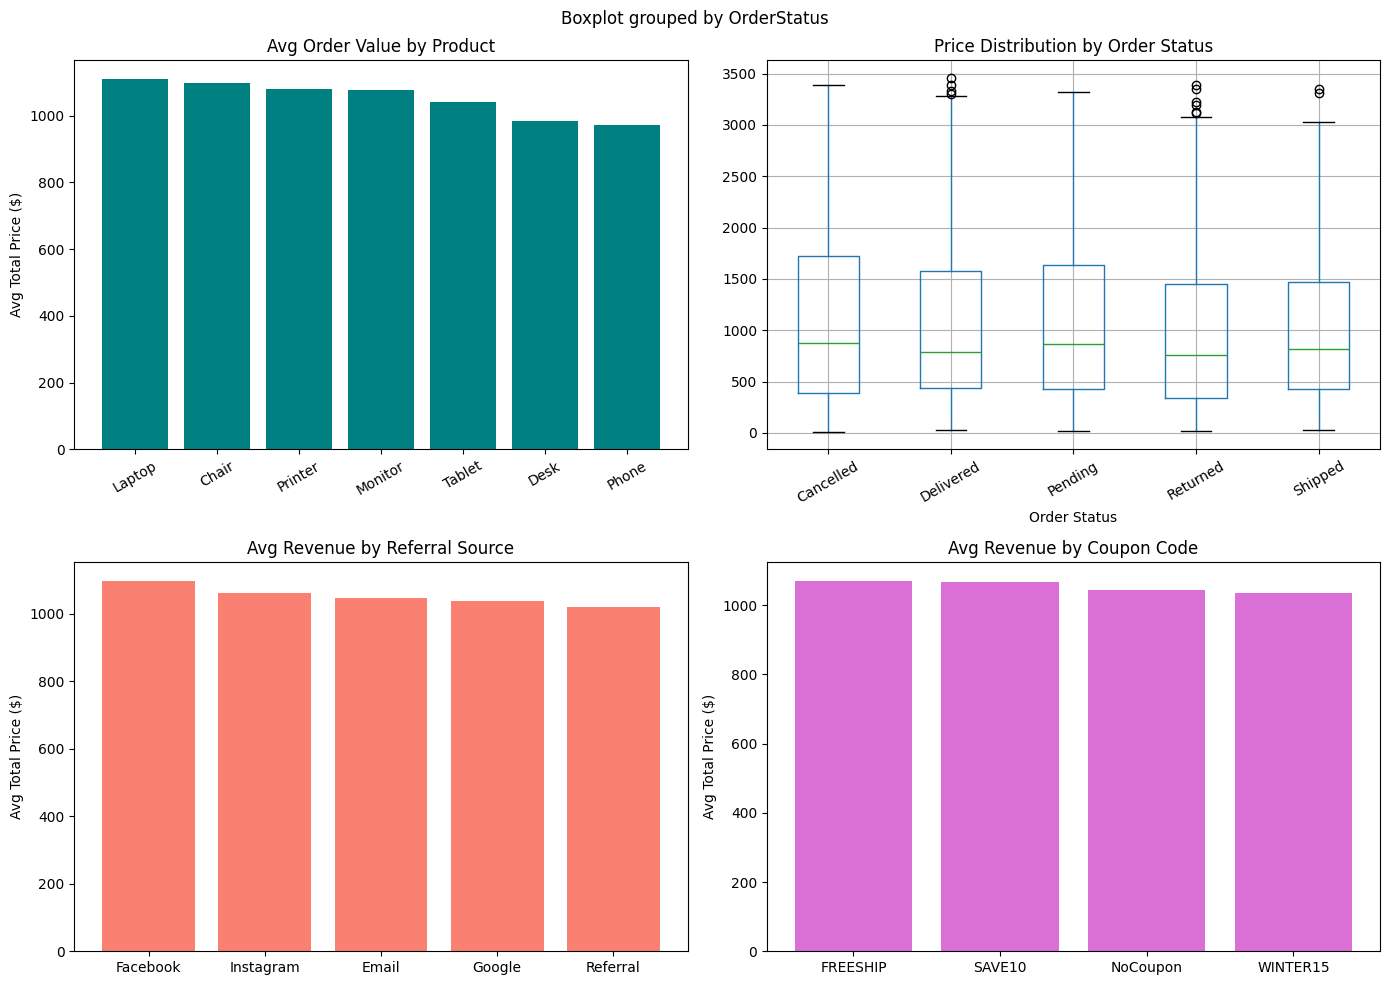

Saved: 02_bivariate_analysis.png


In [17]:
# Coupon Code vs Revenue
avg_coupon = df.groupby('CouponCode')['TotalPrice'].mean().sort_values(ascending=False)
axes[1,1].bar(avg_coupon.index, avg_coupon.values, color='orchid')
axes[1,1].set_title('Avg Revenue by Coupon Code')
axes[1,1].set_ylabel('Avg Total Price ($)')
 
plt.tight_layout()
plt.savefig('02_bivariate_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 02_bivariate_analysis.png")

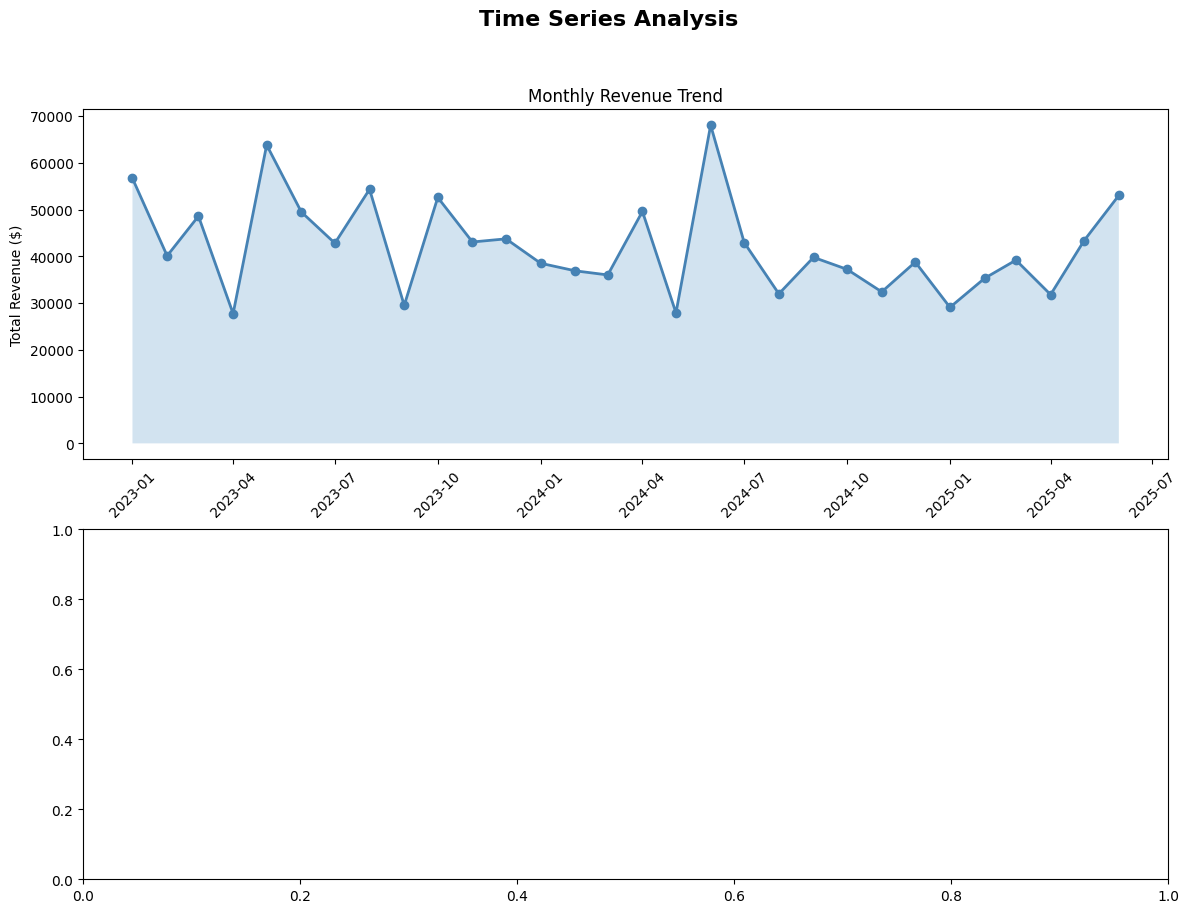

In [18]:
# Time Series Analysis 
monthly_revenue = df.groupby(['Year','Month'])['TotalPrice'].sum().reset_index()
monthly_revenue['Period'] = pd.to_datetime(
    monthly_revenue['Year'].astype(str) + '-' + monthly_revenue['Month'].astype(str)
)
monthly_revenue = monthly_revenue.sort_values('Period')
 
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Time Series Analysis', fontsize=16, fontweight='bold')
 
axes[0].plot(monthly_revenue['Period'], monthly_revenue['TotalPrice'],
             marker='o', linewidth=2, color='steelblue')
axes[0].fill_between(monthly_revenue['Period'], monthly_revenue['TotalPrice'], alpha=0.2)
axes[0].set_title('Monthly Revenue Trend')
axes[0].set_ylabel('Total Revenue ($)')
axes[0].tick_params(axis='x', rotation=45)

In [19]:
# Orders per month
monthly_orders = df.groupby(['Year','Month']).size().reset_index(name='Orders')
monthly_orders['Period'] = pd.to_datetime(
    monthly_orders['Year'].astype(str) + '-' + monthly_orders['Month'].astype(str)
)
monthly_orders = monthly_orders.sort_values('Period')
axes[1].bar(monthly_orders['Period'], monthly_orders['Orders'], color='coral', width=20)
axes[1].set_title('Monthly Order Count')
axes[1].set_ylabel('Number of Orders')
axes[1].tick_params(axis='x', rotation=45)
 
plt.tight_layout()
plt.savefig('03_time_series.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 03_time_series.png")

<Figure size 640x480 with 0 Axes>

Saved: 03_time_series.png


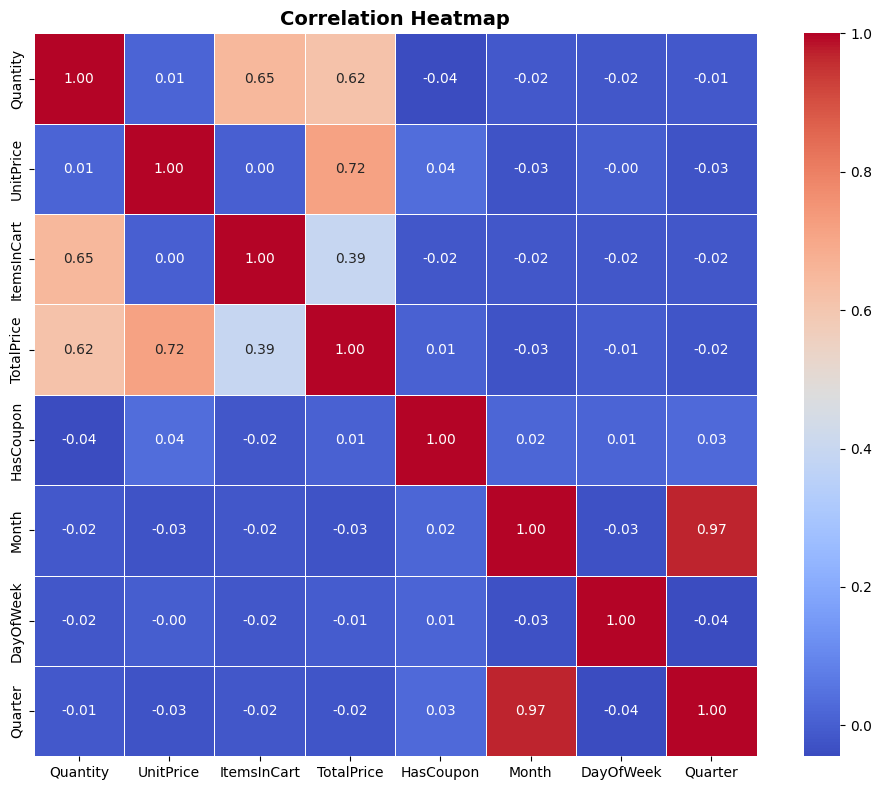

Saved: 04_correlation_heatmap.png


In [20]:
#  Correlation Heatmap 
num_cols = ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice', 'HasCoupon',
            'Month', 'DayOfWeek', 'Quarter']
corr = df[num_cols].corr()
 
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('04_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 04_correlation_heatmap.png")

------

### PART 3: MACHINE LEARNING

### We will train THREE models on this dataset:
 
  MODEL 1 ── Regression  → Predict TotalPrice
  MODEL 2 ── Classification → Predict OrderStatus (Delivered vs rest)
  MODEL 3 ── Clustering   → Customer Segmentation (K-Means)

In [21]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing   import LabelEncoder, StandardScaler
from sklearn.metrics         import (mean_absolute_error, mean_squared_error,
                                     r2_score, classification_report,
                                     confusion_matrix, ConfusionMatrixDisplay)
from sklearn.ensemble        import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model    import LinearRegression, LogisticRegression
from sklearn.cluster         import KMeans
 

In [22]:
# Encode Categorical Columns 
df_ml = df.copy()
le = LabelEncoder()
 
for col in ['Product', 'PaymentMethod', 'OrderStatus', 'CouponCode', 'ReferralSource']:
    df_ml[col + '_enc'] = le.fit_transform(df_ml[col])

In [23]:
# Save encoded mapping for reference
print("\nOrderStatus encoding:")
le.fit(df_ml['OrderStatus'])
for i, c in enumerate(le.classes_):
    print(f"  {i} → {c}")


OrderStatus encoding:
  0 → Cancelled
  1 → Delivered
  2 → Pending
  3 → Returned
  4 → Shipped


#### MODEL 1: REGRESSION — Predict TotalPrice
FEATURES: Quantity, UnitPrice, ItemsInCart, Product, PaymentMethod,
           CouponCode, ReferralSource, Month, Quarter, HasCoupon
 TARGET  : TotalPrice

In [24]:
print("\n" + "="*60)
print("MODEL 1: REGRESSION — Predict TotalPrice")
print("="*60)
 
features_reg = ['Quantity', 'UnitPrice', 'ItemsInCart',
                'Product_enc', 'PaymentMethod_enc', 'CouponCode_enc',
                'ReferralSource_enc', 'Month', 'Quarter', 'HasCoupon']
target_reg = 'TotalPrice'
 
X_reg = df_ml[features_reg]
y_reg = df_ml[target_reg]
 
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)


MODEL 1: REGRESSION — Predict TotalPrice


In [25]:
# Train Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train_r, y_train_r)
y_pred_r = rf_reg.predict(X_test_r)
 
mae  = mean_absolute_error(y_test_r, y_pred_r)
rmse = mean_squared_error(y_test_r, y_pred_r) ** 0.5
r2   = r2_score(y_test_r, y_pred_r)
 
print(f"\nRandom Forest Regressor Results:")
print(f"  MAE  : ${mae:.2f}")
print(f"  RMSE : ${rmse:.2f}")
print(f"  R²   : {r2:.4f}  (1.0 = perfect)")


Random Forest Regressor Results:
  MAE  : $8.54
  RMSE : $14.37
  R²   : 0.9997  (1.0 = perfect)


In [26]:
# Compare with Linear Regression baseline
lr = LinearRegression()
lr.fit(X_train_r, y_train_r)
y_pred_lr = lr.predict(X_test_r)
r2_lr = r2_score(y_test_r, y_pred_lr)
print(f"\n  Linear Regression R² (baseline): {r2_lr:.4f}")
print(f"  Random Forest R² (our model)   : {r2:.4f}")


  Linear Regression R² (baseline): 0.8921
  Random Forest R² (our model)   : 0.9997


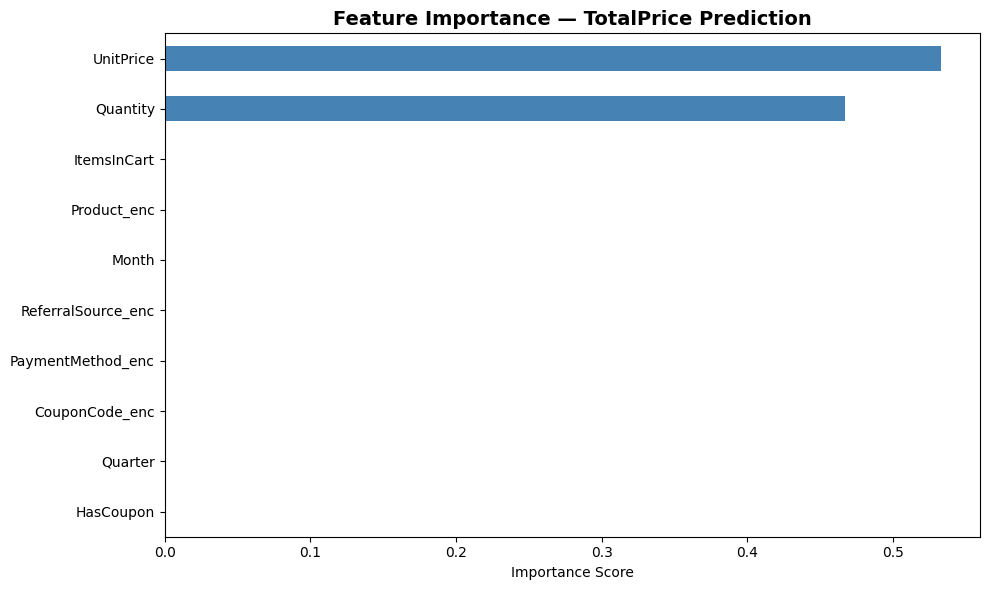

Saved: 05_regression_feature_importance.png


In [27]:
# Feature Importance
importances = pd.Series(rf_reg.feature_importances_, index=features_reg)
importances = importances.sort_values(ascending=True)
 
plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='steelblue')
plt.title('Feature Importance — TotalPrice Prediction', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('05_regression_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 05_regression_feature_importance.png")

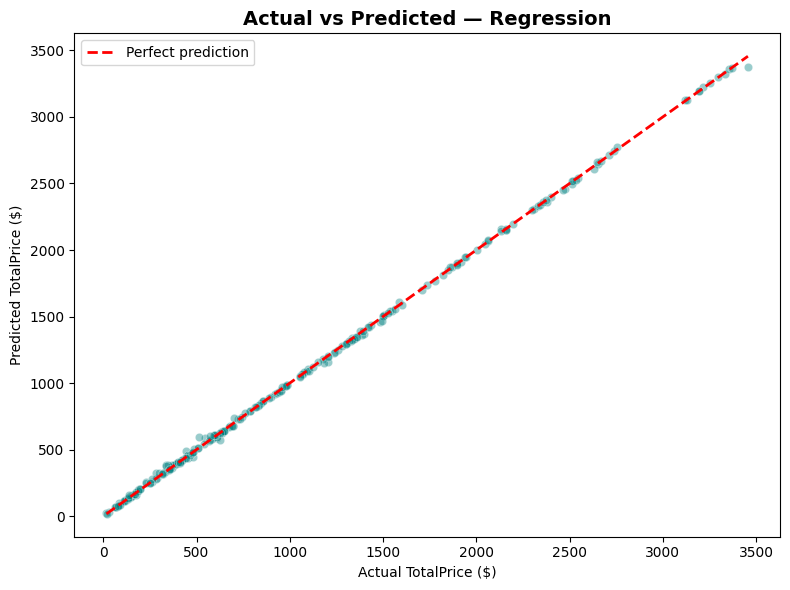

Saved: 06_regression_actual_vs_predicted.png


In [28]:
# Actual vs Predicted scatter
plt.figure(figsize=(8, 6))
plt.scatter(y_test_r, y_pred_r, alpha=0.4, color='teal', edgecolors='white', linewidth=0.5)
plt.plot([y_test_r.min(), y_test_r.max()],
         [y_test_r.min(), y_test_r.max()], 'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual TotalPrice ($)')
plt.ylabel('Predicted TotalPrice ($)')
plt.title('Actual vs Predicted — Regression', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('06_regression_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 06_regression_actual_vs_predicted.png")

#### MODEL 2: CLASSIFICATION — Predict if Order will be Delivered

FEATURES: Quantity, UnitPrice, ItemsInCart, Product, PaymentMethod,
           CouponCode, ReferralSource, Month, Quarter, HasCoupon
 TARGET  : IsDelivered (1 = Delivered, 0 = Not Delivered)

In [29]:
print("\n" + "="*60)
print("MODEL 2: CLASSIFICATION — Will Order be Delivered?")
print("="*60)
 
df_ml['IsDelivered'] = (df_ml['OrderStatus'] == 'Delivered').astype(int)
print("\nClass distribution:")
print(df_ml['IsDelivered'].value_counts())
print(f"  Delivered     : {df_ml['IsDelivered'].sum()}")
print(f"  Not Delivered : {(df_ml['IsDelivered']==0).sum()}")
 
features_clf = ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice',
                'Product_enc', 'PaymentMethod_enc', 'CouponCode_enc',
                'ReferralSource_enc', 'Month', 'Quarter', 'HasCoupon']
target_clf = 'IsDelivered'
 
X_clf = df_ml[features_clf]
y_clf = df_ml[target_clf]
 
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)
 


MODEL 2: CLASSIFICATION — Will Order be Delivered?

Class distribution:
IsDelivered
0    969
1    231
Name: count, dtype: int64
  Delivered     : 231
  Not Delivered : 969


In [30]:
# Train Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train_c, y_train_c)
y_pred_c = rf_clf.predict(X_test_c)
 
print("\nClassification Report:")
print(classification_report(y_test_c, y_pred_c,
                            target_names=['Not Delivered', 'Delivered']))
 
# Cross-validation accuracy
cv_scores = cross_val_score(rf_clf, X_clf, y_clf, cv=5, scoring='accuracy')
print(f"5-Fold Cross-Validation Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


Classification Report:
               precision    recall  f1-score   support

Not Delivered       0.81      0.99      0.89       194
    Delivered       0.00      0.00      0.00        46

     accuracy                           0.80       240
    macro avg       0.40      0.49      0.44       240
 weighted avg       0.65      0.80      0.72       240

5-Fold Cross-Validation Accuracy: 0.7983 ± 0.0057


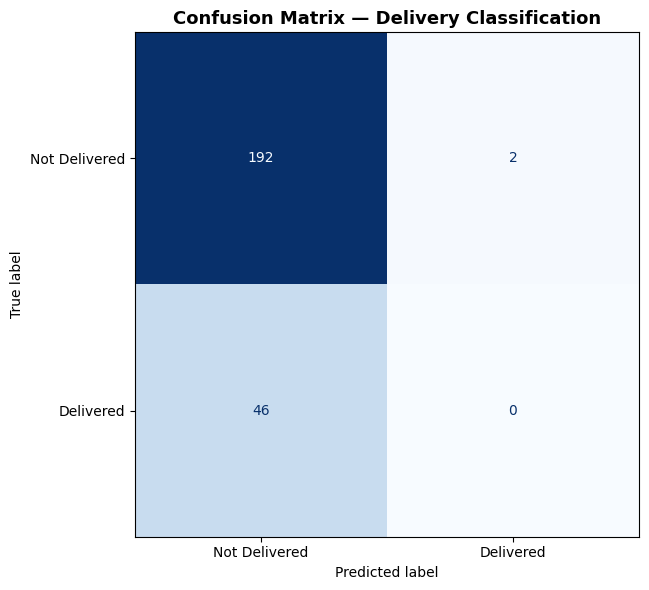

Saved: 07_classification_confusion_matrix.png


In [31]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test_c, y_pred_c)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Not Delivered', 'Delivered'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Delivery Classification', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('07_classification_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 07_classification_confusion_matrix.png")

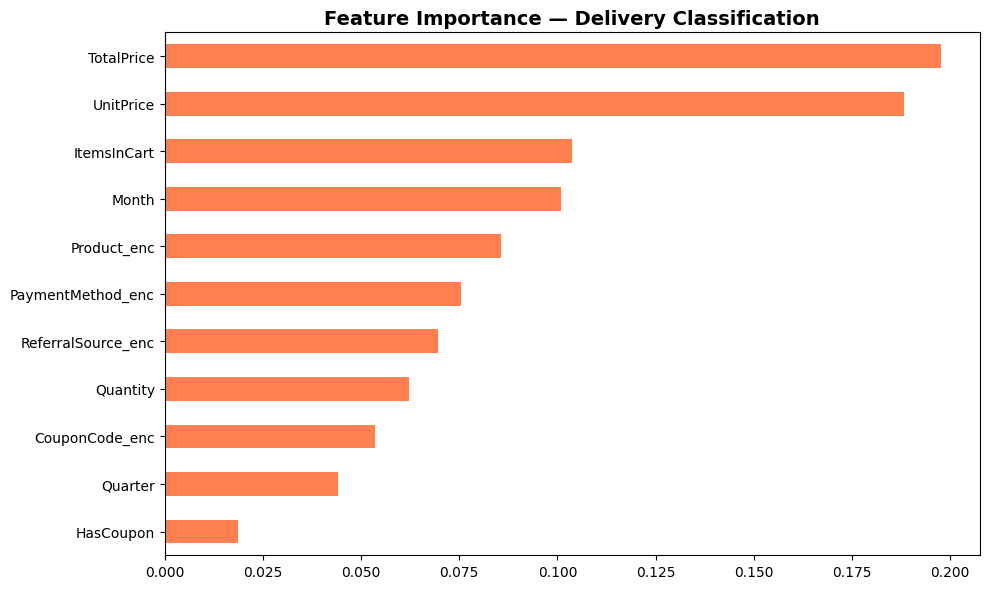

Saved: 08_classification_feature_importance.png


In [32]:
# Feature importance for classifier
imp_clf = pd.Series(rf_clf.feature_importances_, index=features_clf).sort_values(ascending=True)
plt.figure(figsize=(10, 6))
imp_clf.plot(kind='barh', color='coral')
plt.title('Feature Importance — Delivery Classification', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('08_classification_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 08_classification_feature_importance.png")

#### MODEL 3: CLUSTERING — Customer Segmentation (K-Means)

Group customers by their purchasing behavior.
 FEATURES: Total spend, order count, avg order value, avg quantity,
           items in cart, has coupon

In [33]:
# Build customer-level features
customer_df = df_ml.groupby('CustomerID').agg(
    TotalSpend    = ('TotalPrice',    'sum'),
    OrderCount    = ('OrderID',       'count'),
    AvgOrderValue = ('TotalPrice',    'mean'),
    AvgQuantity   = ('Quantity',      'mean'),
    AvgItemsInCart= ('ItemsInCart',   'mean'),
    CouponUsage   = ('HasCoupon',     'mean'),   # fraction of orders with coupon
).reset_index()
 
print(f"\nCustomer-level data shape: {customer_df.shape}")
print(customer_df.describe())
 
# Scale features
scaler = StandardScaler()
X_cluster = scaler.fit_transform(customer_df[['TotalSpend','OrderCount',
                                               'AvgOrderValue','AvgQuantity',
                                               'AvgItemsInCart','CouponUsage']])


Customer-level data shape: (1189, 7)
        TotalSpend   OrderCount  AvgOrderValue  AvgQuantity  AvgItemsInCart  \
count  1189.000000  1189.000000    1189.000000  1189.000000     1189.000000   
mean   1063.719058     1.009251    1055.503844     2.947855        5.489066   
std     829.554305     0.095779     818.116142     1.403689        2.274300   
min      11.390000     1.000000      11.390000     1.000000        1.000000   
25%     414.470000     1.000000     410.910000     2.000000        4.000000   
50%     834.120000     1.000000     826.400000     3.000000        5.000000   
75%    1599.850000     1.000000    1580.350000     4.000000        7.000000   
max    5723.230000     2.000000    3456.400000     5.000000       10.000000   

       CouponUsage  
count  1189.000000  
mean      0.742641  
std       0.435917  
min       0.000000  
25%       0.000000  
50%       1.000000  
75%       1.000000  
max       1.000000  


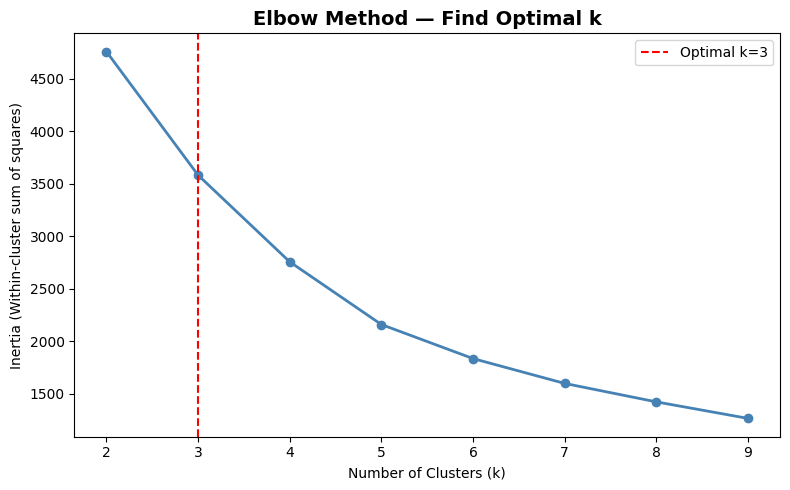

Saved: 09_clustering_elbow.png


In [34]:
# Elbow Method to find optimal k
inertias = []
K_range = range(2, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)
 
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, marker='o', linewidth=2, color='steelblue')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-cluster sum of squares)')
plt.title('Elbow Method — Find Optimal k', fontsize=14, fontweight='bold')
plt.xticks(K_range)
plt.axvline(x=3, color='red', linestyle='--', label='Optimal k=3')
plt.legend()
plt.tight_layout()
plt.savefig('09_clustering_elbow.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 09_clustering_elbow.png")
 

In [35]:
# Train final K-Means with k=3
km_final = KMeans(n_clusters=3, random_state=42, n_init=10)
customer_df['Cluster'] = km_final.fit_predict(X_cluster)

In [36]:
# Analyze clusters
cluster_summary = customer_df.groupby('Cluster').agg(
    CustomerCount = ('CustomerID',    'count'),
    AvgTotalSpend = ('TotalSpend',    'mean'),
    AvgOrders     = ('OrderCount',    'mean'),
    AvgOrderValue = ('AvgOrderValue', 'mean'),
    AvgItemsInCart= ('AvgItemsInCart','mean'),
    CouponUsage   = ('CouponUsage',   'mean'),
).round(2)
 
print("\nCluster Summary:")
print(cluster_summary.to_string())


Cluster Summary:
         CustomerCount  AvgTotalSpend  AvgOrders  AvgOrderValue  AvgItemsInCart  CouponUsage
Cluster                                                                                     
0                  743         559.17        1.0         559.17            4.58         0.74
1                  435        1907.50        1.0        1907.50            7.05         0.75
2                   11        1775.98        2.0         887.99            5.05         0.73


In [37]:
# Name clusters based on spend level
cluster_names = {
    cluster_summary['AvgTotalSpend'].idxmax(): 'High-Value (VIP)',
    cluster_summary['AvgTotalSpend'].idxmin(): 'Low-Value (Occasional)',
}
mid_cluster = [c for c in [0,1,2] if c not in cluster_names][0]
cluster_names[mid_cluster] = 'Mid-Value (Regular)'
 
customer_df['SegmentName'] = customer_df['Cluster'].map(cluster_names)
print("\nCluster Labels:", cluster_names)


Cluster Labels: {1: 'High-Value (VIP)', 0: 'Low-Value (Occasional)', 2: 'Mid-Value (Regular)'}


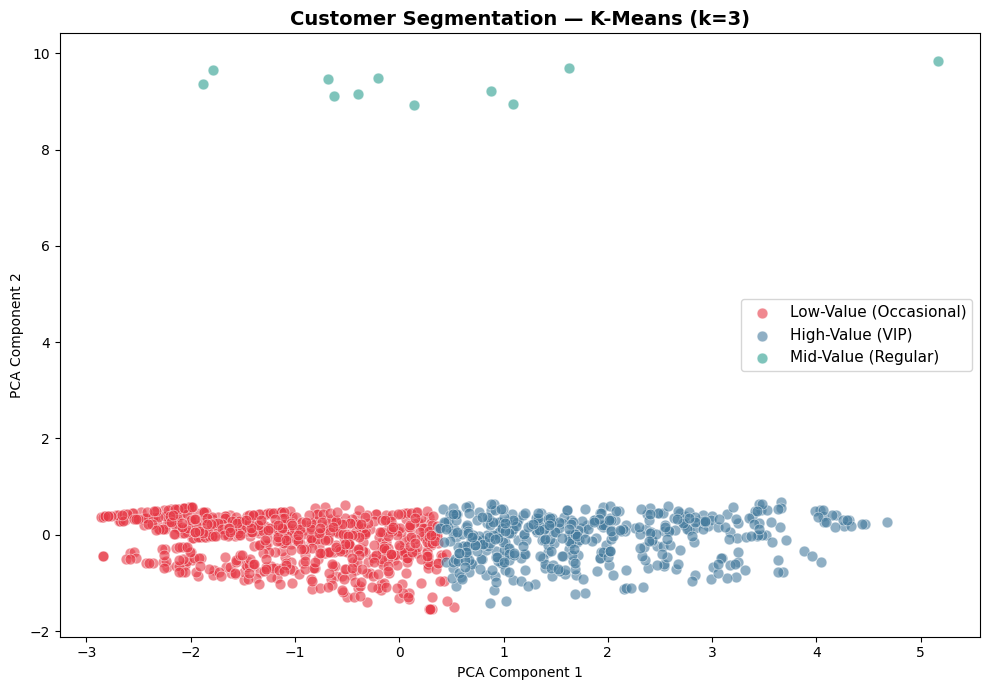

Saved: 10_clustering_segments.png


In [38]:
# Cluster visualization (using PCA for 2D)
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster)
 
colors = ['#E63946', '#457B9D', '#2A9D8F']
labels = [cluster_names[i] for i in range(3)]
 
plt.figure(figsize=(10, 7))
for i in range(3):
    mask = customer_df['Cluster'] == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colors[i], label=labels[i], alpha=0.6, s=60, edgecolors='white', linewidth=0.5)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Customer Segmentation — K-Means (k=3)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('10_clustering_segments.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 10_clustering_segments.png")
 

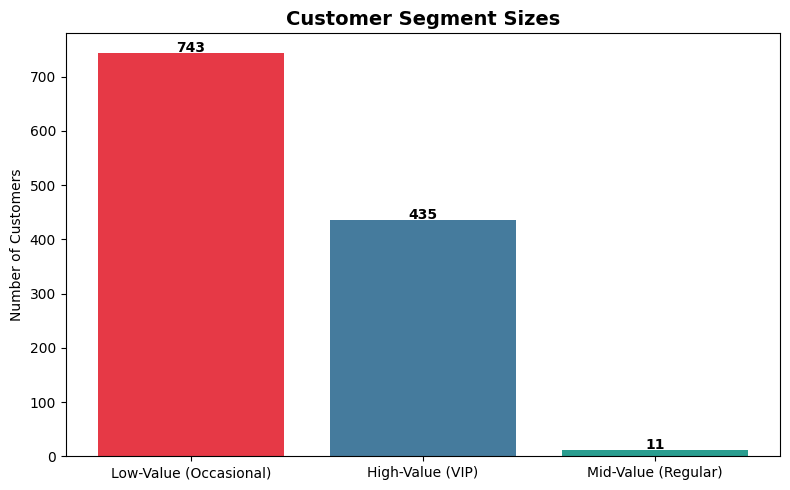

Saved: 11_segment_sizes.png


In [39]:
# Segment size bar chart
seg_counts = customer_df['SegmentName'].value_counts()
plt.figure(figsize=(8, 5))
plt.bar(seg_counts.index, seg_counts.values, color=['#E63946', '#457B9D', '#2A9D8F'])
plt.title('Customer Segment Sizes', fontsize=14, fontweight='bold')
plt.ylabel('Number of Customers')
for i, v in enumerate(seg_counts.values):
    plt.text(i, v + 2, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('11_segment_sizes.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 11_segment_sizes.png")

####  PART 4: BUSINESS INSIGHTS SUMMARY

In [40]:
print("\n" + "="*60)
print("BUSINESS INSIGHTS SUMMARY")
print("="*60)
 
print(f"\n1. TOP PRODUCT by revenue:")
top_prod = df.groupby('Product')['TotalPrice'].sum().idxmax()
top_rev  = df.groupby('Product')['TotalPrice'].sum().max()
print(f"   → {top_prod} (${top_rev:,.0f} total revenue)")
 
print(f"\n2. MOST POPULAR PAYMENT METHOD:")
print(f"   → {df['PaymentMethod'].value_counts().idxmax()}")
 
print(f"\n3. BEST REFERRAL SOURCE by avg order value:")
best_ref = df.groupby('ReferralSource')['TotalPrice'].mean().idxmax()
best_ref_val = df.groupby('ReferralSource')['TotalPrice'].mean().max()
print(f"   → {best_ref} (avg ${best_ref_val:,.2f})")
 
print(f"\n4. CANCELLATION RATE:")
cancel_rate = (df['OrderStatus'] == 'Cancelled').mean() * 100
print(f"   → {cancel_rate:.1f}%")
 
print(f"\n5. COUPON USAGE RATE:")
coupon_rate = (df['CouponCode'] != 'NoCoupon').mean() * 100
print(f"   → {coupon_rate:.1f}% of orders used a coupon")
 
print(f"\n6. ML MODEL SUMMARY:")
print(f"   Regression  R² = {r2:.4f}  (TotalPrice prediction)")
print(f"   Classification CV Accuracy = {cv_scores.mean():.4f}  (Delivery prediction)")
print(f"   Clustering  K=3 segments  (Customer segmentation)")
 
print(f"\n7. CUSTOMER SEGMENTS:")
for seg, row in cluster_summary.iterrows():
    name = cluster_names[seg]
    print(f"   Cluster {seg} ({name}): {int(row['CustomerCount'])} customers, "
          f"avg spend=${row['AvgTotalSpend']:,.0f}")
 
print("\n" + "="*60)
print("All charts saved as PNG files. Analysis complete!")
print("="*60)


BUSINESS INSIGHTS SUMMARY

1. TOP PRODUCT by revenue:
   → Chair ($195,620 total revenue)

2. MOST POPULAR PAYMENT METHOD:
   → Online

3. BEST REFERRAL SOURCE by avg order value:
   → Facebook (avg $1,098.29)

4. CANCELLATION RATE:
   → 20.8%

5. COUPON USAGE RATE:
   → 74.2% of orders used a coupon

6. ML MODEL SUMMARY:
   Regression  R² = 0.9997  (TotalPrice prediction)
   Classification CV Accuracy = 0.7983  (Delivery prediction)
   Clustering  K=3 segments  (Customer segmentation)

7. CUSTOMER SEGMENTS:
   Cluster 0 (Low-Value (Occasional)): 743 customers, avg spend=$559
   Cluster 1 (High-Value (VIP)): 435 customers, avg spend=$1,908
   Cluster 2 (Mid-Value (Regular)): 11 customers, avg spend=$1,776

All charts saved as PNG files. Analysis complete!


In [43]:

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df = pd.read_excel('Dataset for Data Analytics (1).xlsx', parse_dates=['Date'])
df['CouponCode'] = df['CouponCode'].fillna('NoCoupon')
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['Quarter'] = df['Date'].dt.quarter
df['HasCoupon'] = (df['CouponCode'] != 'NoCoupon').astype(int)

le = LabelEncoder()
for col in ['Product','PaymentMethod','OrderStatus','CouponCode','ReferralSource']:
    df[col+'_enc'] = le.fit_transform(df[col])

df['IsDelivered'] = (df['OrderStatus'] == 'Delivered').astype(int)

# Regression predictions
features_reg = ['Quantity','UnitPrice','ItemsInCart','Product_enc','PaymentMethod_enc','CouponCode_enc','ReferralSource_enc','Month','Quarter','HasCoupon']
from sklearn.ensemble import RandomForestRegressor
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(df[features_reg], df['TotalPrice'])
df['Predicted_TotalPrice'] = rf_reg.predict(df[features_reg]).round(2)

# Classification predictions
features_clf = ['Quantity','UnitPrice','ItemsInCart','TotalPrice','Product_enc','PaymentMethod_enc','CouponCode_enc','ReferralSource_enc','Month','Quarter','HasCoupon']
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(df[features_clf], df['IsDelivered'])
df['Predicted_IsDelivered'] = rf_clf.predict(df[features_clf])
df['Predicted_DeliveryLabel'] = df['Predicted_IsDelivered'].map({1:'Delivered', 0:'Not Delivered'})

# Clustering
customer_df = df.groupby('CustomerID').agg(
    TotalSpend=('TotalPrice','sum'), OrderCount=('OrderID','count'),
    AvgOrderValue=('TotalPrice','mean'), AvgQuantity=('Quantity','mean'),
    AvgItemsInCart=('ItemsInCart','mean'), CouponUsage=('HasCoupon','mean')
).reset_index()
scaler = StandardScaler()
X_cluster = scaler.fit_transform(customer_df[['TotalSpend','OrderCount','AvgOrderValue','AvgQuantity','AvgItemsInCart','CouponUsage']])
km = KMeans(n_clusters=3, random_state=42, n_init=10)
customer_df['Cluster'] = km.fit_predict(X_cluster)
spend_map = customer_df.groupby('Cluster')['TotalSpend'].mean()
max_c = spend_map.idxmax(); min_c = spend_map.idxmin()
mid_c = [c for c in [0,1,2] if c not in [max_c, min_c]][0]
cluster_names = {max_c:'High-Value (VIP)', min_c:'Low-Value (Occasional)', mid_c:'Mid-Value (Regular)'}
customer_df['CustomerSegment'] = customer_df['Cluster'].map(cluster_names)
df = df.merge(customer_df[['CustomerID','Cluster','CustomerSegment']], on='CustomerID', how='left')

# Final submission
submission = df[['OrderID','CustomerID','Date','Product','Quantity','UnitPrice','TotalPrice',
                 'Predicted_TotalPrice','OrderStatus','Predicted_DeliveryLabel','CustomerSegment']].copy()
submission.to_csv('submission.csv', index=False)
print('submission.csv created, shape:', submission.shape)
print(submission.head())



submission.csv created, shape: (1200, 11)
     OrderID CustomerID       Date  Product  Quantity  UnitPrice  TotalPrice  \
0  ORD200000     C72649 2023-01-04  Monitor         5     570.62     2853.10   
1  ORD200001     C75739 2024-08-23    Phone         2     151.35      302.70   
2  ORD200002     C81728 2024-02-27   Tablet         5     550.68     2753.40   
3  ORD200003     C33540 2023-10-15    Chair         1     273.19      273.19   
4  ORD200004     C81840 2025-05-08  Printer         4     626.01     2504.04   

   Predicted_TotalPrice OrderStatus Predicted_DeliveryLabel  \
0               2857.05     Shipped           Not Delivered   
1                302.40     Shipped           Not Delivered   
2               2758.45   Cancelled           Not Delivered   
3                275.98    Returned           Not Delivered   
4               2510.00   Delivered               Delivered   

          CustomerSegment  
0        High-Value (VIP)  
1  Low-Value (Occasional)  
2        High-